In [1]:
# from models.imagenet import mobilenetv2
from  mobilenetv2.models.imagenet.mbnetv2 import mbnetv2
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import math, os
import pandas as pd
import numpy as np
import cv2

In [2]:
cfgs = [
            [1,  16, 1, 1],
            [6,  24, 2, 2],
            [6,  32, 3, 2],
            [6,  64, 4, 2],
            
            [6,  96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]
cfgs = [cfg[2] for cfg in cfgs]

In [3]:
def convert_state_dict(pretrained_sd,cfgs):
    new_sd = {}
    for k, v in pretrained_sd.items():
        # print(f"Converting {k} to ")
        # print(v)
        # First layer mapping
        if k.startswith('features.0'):
            new_key = k.replace('features.0', 'first_conv')
            new_sd[new_key] = v
        # Bottleneck blocks mapping (may need to adjust for all indices)
        elif k.startswith('features'):
            parts = k.split('.')
            block_idx = int(parts[1]) - 1      # because features.0 is first_conv
            # Find the corresponding config
            idx_1 = 0
            idx_2 = 0
            for i, cfg in enumerate(cfgs):
                if sum(cfgs[:i+1]) > block_idx:
                    idx_1 = i
                    idx_2 = block_idx - sum(cfgs[:i])
                    break

            rest = '.'.join(parts[2:])
            new_key = f'bottleneck_sequential_blocks.{idx_1}.{idx_2}.{rest}'
            new_sd[new_key] = v
        # Last layers mapping (if present)
        elif k.startswith('conv'):
            new_sd[k] = v
        elif k.startswith('classifier'):
            new_sd[k] = v
        else:
            # Handle or ignore unexpected keys
            pass
    return new_sd

In [4]:
pretrained_sd = torch.load('mobilenetv2/pretrained/mobilenetv2-c5e733a8.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data_dir = 'cityscapes_data/data/'


/tmp/ipykernel_96444/2542683847.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_sd = torch.load('mobilenetv2/pretrained/mobilenetv2-c5e733a8.pth')


## Prepare CityScapes Data
Before proceeding we need to prepare the depth dataset from the depth disparity data provided. I have taken snippets from the following repository to do this. 
- CityScapes Preprocessing - [link](https://github.com/itberrios/CV_projects/blob/main/multitask_depth_seg/data_exploration/cityscapes_dataset_depth_intuition.ipynb)
- Crop noisy parts and resize (seems to be better than relecting on the borders)
- Inpaint and Blur disparity to reduce noise
- Scale to get True disparity values
- Compute depth = b.f/disparity
    - d: depth (meters), b: baseline (meters), f: focal length (pixels), disparity (pixels)
    clip to (0, 500)


In [5]:

def load_cityscapes_numpy(data_dir):
    images = []
    labels = []
    
    # Assuming structure: data_dir/images/*.npy and data_dir/labels/*.npy
    image_dir = os.path.join(data_dir, 'image')
    label_dir = os.path.join(data_dir, 'label')
    
    for filename in os.listdir(image_dir):
        if filename.endswith('.npy'):
            # Load image
            img = np.load(os.path.join(image_dir, filename))
            images.append(img)
            
            # Load corresponding label
            label_file = filename  # assuming same naming
            label = np.load(os.path.join(label_dir, label_file))
            labels.append(label)
    
    return np.array(images), np.array(labels)

In [6]:
class CScapesGTDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, target_transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.target_transform = target_transform
        
        # Build paths for image, depth, and label folders
        self.image_dir = os.path.join(root_dir, split, 'image')
        self.depth_dir = os.path.join(root_dir, split, 'depth') 
        self.label_dir = os.path.join(root_dir, split, 'label')
        
        # Count how many files exist (assuming all folders have same count)
        self.num_samples = 0
        while os.path.exists(os.path.join(self.image_dir, f"{self.num_samples}.npy")):
            self.num_samples += 1
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Build file paths using index
        image_path = os.path.join(self.image_dir, f"{idx}.npy")
        depth_path = os.path.join(self.depth_dir, f"{idx}.npy")
        label_path = os.path.join(self.label_dir, f"{idx}.npy")
        
        # Lazy load: only load when requested
        image = np.load(image_path)
        depth = np.load(depth_path)
        label = np.load(label_path)
        
        # Apply transforms if provided
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
            
        # Convert to tensors
        image = torch.from_numpy(image).float().permute(2, 0, 1)  # Convert HWC to CHW
        depth = torch.from_numpy(depth).float().permute(2, 0, 1)  # Convert HWC to CHW
        label = torch.from_numpy(label).long().unsqueeze(0)  # Usually labels are long for classification

        return image, depth, label

In [435]:
class CityscapesDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, target_transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.target_transform = target_transform
        
        # Build paths for image, depth, and label folders
        self.image_dir = os.path.join(root_dir, split, 'image')
        self.depth_dir = os.path.join(root_dir, split, 'depth') 
        self.label_dir = os.path.join(root_dir, split, 'label')
        
        # Count how many files exist (assuming all folders have same count)
        self.num_samples = 0
        while os.path.exists(os.path.join(self.image_dir, f"{self.num_samples}.npy")):
            self.num_samples += 1
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Build file paths using index
        image_path = os.path.join(self.image_dir, f"{idx}.npy")
        disp_path = os.path.join(self.depth_dir, f"{idx}.npy")
        label_path = os.path.join(self.label_dir, f"{idx}.npy")
        
        # Lazy load: only load when requested
        image = self.rescale_image(np.load(image_path))
        disparity = np.load(disp_path)
        label = self.rescale_image(np.load(label_path),interp_type = cv2.INTER_NEAREST_EXACT)
        
        depth = self.get_depth(disparity)
        # Apply transforms if provided
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
            
        # Convert to tensors
        image = torch.from_numpy(image).float().permute(2, 0, 1)  # Convert HWC to CHW
        depth = torch.from_numpy(depth).unsqueeze(-1).permute(2, 0, 1)  # Convert HWC to CHW
        label = torch.from_numpy(label).long().unsqueeze(0)  # Usually labels are long for classification


        return image, depth, label

    def rescale_image(self,image,interp_type = cv2.INTER_LINEAR):
        if len(image.shape) == 3:
            h, w,_ = image.shape
        else:
            print(image.shape)
            h,w = image.shape
        h2, w2 = int(h*0.9), int(w*0.95)

        image = cv2.resize(image[10:h2,25:w2],(w,h),interpolation=interp_type)

        return image

    def get_depth(self, disparity):
        # get sizes
        print(disparity.shape)
        h, w,_ = disparity.shape
        h2, w2 = int(h*0.9), int(w*0.95)


        # remove most noisy bottom area
        # crop bottom noise and resize
        disparity = cv2.resize(disparity[10:h2, 25:w2], (w,h))
        inpaint_radius = 12
        disparity = disparity.astype(np.float32)

        print(disparity.dtype)
        disparity = cv2.inpaint(disparity, np.uint8(255*(disparity <= 1)), inpaintRadius=inpaint_radius, flags=cv2.INPAINT_TELEA)


        # # blur to reduce noise
        # disparity = cv2.medianBlur(disparity, 3)
        disparity = cv2.bilateralFilter(disparity, d=4, sigmaColor=15, sigmaSpace=75)
        # disparity = cv2.GaussianBlur(disparity, (7, 7), 1.5)

        # disparity[disparity > 0] = (disparity[disparity > 0] - 1) / 256
        baseline = 0.209313 # meters


        # focal lengths (pixels)
        fx = 2262.52 
        fy = 2265.3017905988554 


        depth = baseline * fx / (disparity + 0.1)

        depth = np.clip(depth, 0, 5000)/10
        print(depth)
        return depth

In [436]:
def depth_to_display(depth_1x1HW: torch.Tensor, cmap='magma'):
    # depth_1x1HW: (1,1,H,W)
    d = depth_1x1HW.detach().cpu().float().squeeze(0).squeeze(0)   # (H,W)
    # remove NaN/Inf and clip robustly using percentiles
    a = d.numpy()
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    # robust range (ignore outliers)
    # vmin, vmax = np.percentile(a, 2), np.percentile(a, 98)
    vmin = np.min(a)
    vmax = np.max(a)
    if vmax <= vmin:
        vmin, vmax = float(a.min()), float(a.max())
    a = np.clip(a, vmin, vmax)
    norm = (a - vmin) / (vmax - vmin + 1e-12)

    # grayscale uint8 for saving
    gray_u8 = (norm * 255).astype(np.uint8)

    # optional colored visualization
    plt.figure(figsize=(4,4))
    plt.imshow(norm, cmap=cmap)  # e.g., 'inferno', 'magma', 'turbo', 'viridis'
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # return a  # HxW uint8


In [437]:
def display_three_tensors(image_tensor, seg_tensor, depth_tensor, titles=None):

    if titles is None:
        titles = ['Image', 'Segmentation', 'Depth']
    
    # Process image tensor
    image_np = image_tensor.permute(1,2,0).detach().cpu().numpy()
    seg_np = seg_tensor.detach().cpu().squeeze(0).numpy()  # Assuming single channel
    disparity_np = depth_tensor.detach().cpu().squeeze(0).numpy()  #
    
    
    # Display image
    _, ax = plt.subplots(1, 3, figsize=(20, 8))
    ax[0].imshow(image_np)
    ax[1].imshow(seg_np, cmap='tab20')
    ax[2].imshow(disparity_np, cmap='hot')
    
    plt.tight_layout()
    plt.show()

In [446]:
dataset = CityscapesDataset(data_dir)

images, depths, labels = dataset[15]

(128, 256)
(128, 256, 1)
float32
[[291.5888   291.2307   287.08627  ... 267.3216   267.7464   267.5185  ]
 [290.54163  287.0091   279.41153  ... 266.7148   267.30487  267.30493 ]
 [283.48093  276.53232  275.40692  ... 265.6396   267.1089   265.99542 ]
 ...
 [110.74412  110.79745  110.78813  ... 109.8279   109.68959  109.588806]
 [109.79519  109.79266  109.816635 ... 108.91881  108.884766 108.911354]
 [109.43783  109.36455  109.31177  ... 108.57644  108.55461  108.58372 ]]


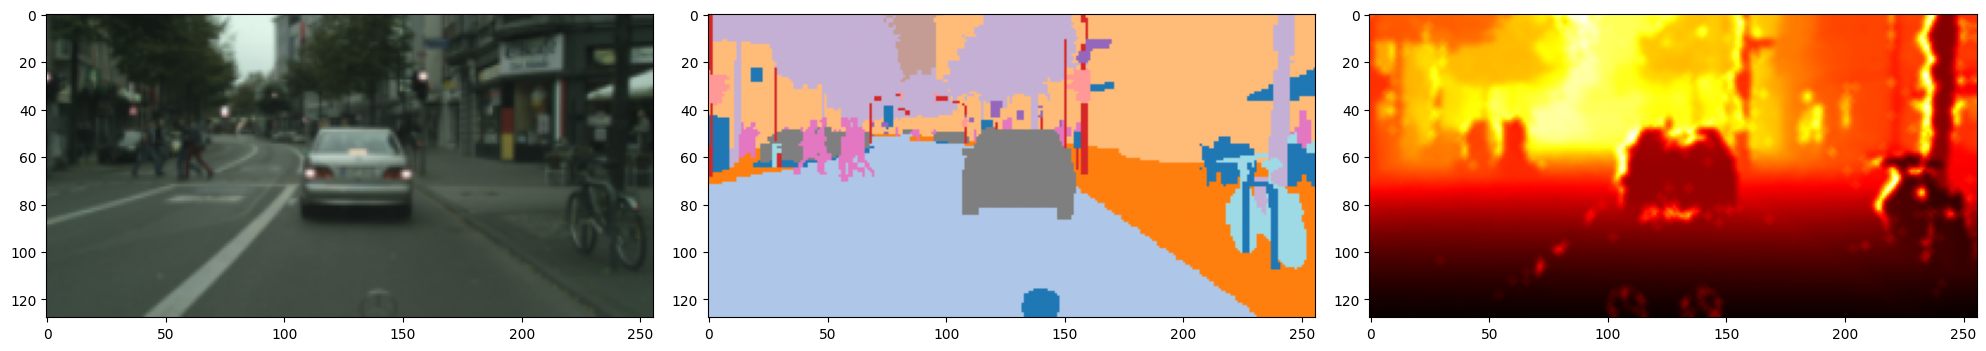

In [447]:
display_three_tensors(images, labels, depths)

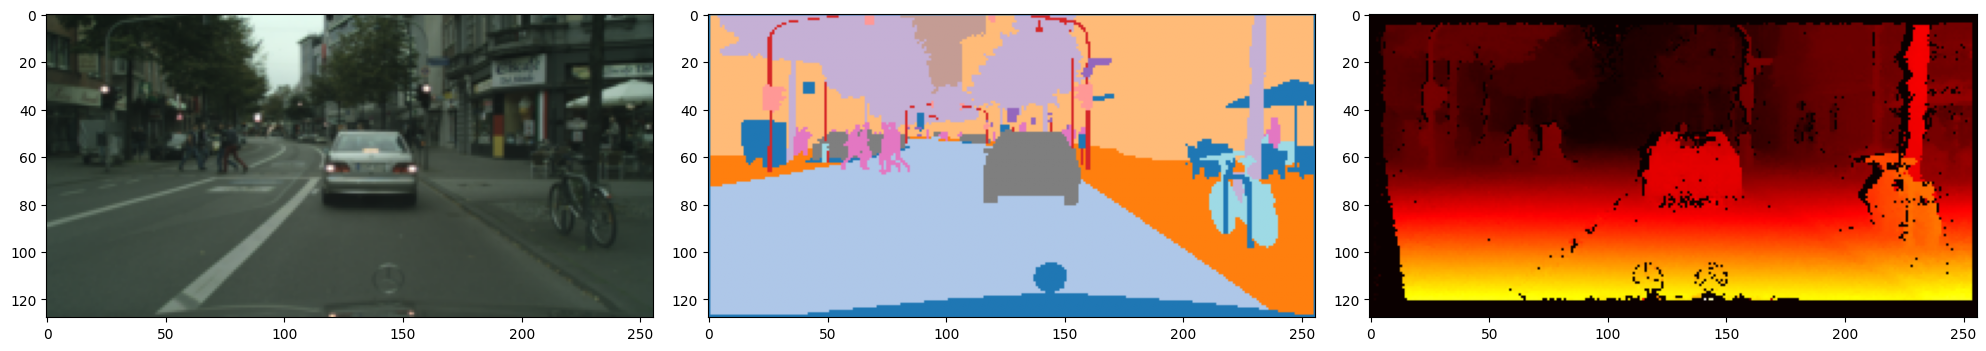

In [448]:
gt_dataset = CScapesGTDataset(data_dir)
gt_image,gt_disp,gt_seg = gt_dataset[15]
display_three_tensors(gt_image,gt_seg,gt_disp)

In [125]:
images.shape, depths.shape, labels.shape

(torch.Size([3, 128, 256]),
 torch.Size([1, 128, 256]),
 torch.Size([1, 128, 256]))

In [449]:
train_dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

In [450]:
for batch in train_dataloader:
    images, depths, labels = batch
    print(images.shape, depths.shape, labels.shape)
    break

(128, 256)
(128, 256, 1)
float32
(128, 256)
[[319.9972   324.26083  315.466    ... 330.18814  331.1233   331.52567 ]
 [327.4085   329.45093  320.78116  ... 330.14093  330.9337   331.29172 ]
 [345.51086  343.23416  330.64767  ... 330.2669   330.99405  331.23065 ]
 ...
 [111.799515 111.80526  111.76863  ... 114.152695 114.04381  113.99412 ]
 [110.74928  110.75093  110.75757  ... 113.19362  113.06702  112.910416]
 [110.26282  110.29051  110.321884 ... 112.79468  112.65489  112.476585]]
(128, 256, 1)
float32
[[353.32224  353.441    354.12506  ... 224.37036  224.56792  224.55771 ]
 [353.84177  353.7471   354.40332  ... 224.2417   224.46272  224.52127 ]
 [355.20135  354.96332  355.49664  ... 224.126    224.24727  224.31038 ]
 ...
 [101.59211  101.593796 101.60945  ... 104.91339  104.86918  104.83992 ]
 [100.83281  100.82472  100.82936  ... 104.11562  104.05904  104.032104]
 [100.49057  100.514015 100.53758  ... 103.713036 103.71571  103.70796 ]]
(128, 256)
(128, 256, 1)
float32
[[382.99597  

In [451]:
# # Load image
# img_path = 'nyu_data/data/nyu2_train/basement_0001a_out/1.jpg'
# img = Image.open(img_path).convert('RGB')

# # Display the image
# plt.imshow(img)
# plt.axis('off')
# plt.show()
# # Define transforms matching training input requirements
# # input_size = 224  # or your chosen input size
# transform = transforms.Compose([
#     # transforms.Resize(input_size),
#     # transforms.CenterCrop(input_size),
#     transforms.ToTensor() #,
#     # transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet means
#                         #  std=[0.229, 0.224, 0.225])   # ImageNet stds
# ])

# # Apply transforms
# img_tensor = transform(img).unsqueeze(0)  # add batch dimension

# # Move to GPU if available
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# img_tensor = img_tensor.to(device)


### Model Classes


In [452]:
def conv_3x3_bn(inp, oup, stride):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 3, stride, 1, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )


def conv_1x1_bn(inp, oup):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 1, 1, 0, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )

class PixelShuffleX2(nn.Module):
    def __init__(self, upscale_factor=2):
        super().__init__()
        self.ps = nn.PixelShuffle(upscale_factor)

    def forward(self, x):
        x = self.ps(x)
        return x

class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        assert stride in [1, 2]

        hidden_dim = round(inp * expand_ratio)
        self.identity = stride == 1 and inp == oup

        if expand_ratio == 1:
            self.conv = nn.Sequential(
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
        else:
            self.conv = nn.Sequential(
                # pw
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
    
    def forward(self, x):
        if self.identity:
            return x + self.conv(x)
        else:
            return self.conv(x)

In [453]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        pixel = PixelShuffleX2
        bottleneck = InvertedResidual

        self.layer1 = nn.Sequential(
            pixel(2),
            # nn.GroupNorm(8,80),
            bottleneck(80, 24, stride=1, expand_ratio=1),
            bottleneck(24, 24, stride=1, expand_ratio=6),
            bottleneck(24, 24, stride=1, expand_ratio=6),
            bottleneck(24, 24, stride=1, expand_ratio=6)
        )
        self.depth_conv_1 = nn.Conv2d(24, 1,kernel_size=1,bias=False)
        self.segm_conv_1 = nn.Conv2d(24, 19, kernel_size=1,bias=False)

        self.layer2 = nn.Sequential(
            pixel(2),
            # nn.GroupNorm(6,30),
            bottleneck(30, 16, stride=1, expand_ratio=3),
            bottleneck(16, 16, stride=1, expand_ratio=6),
            bottleneck(16, 16, stride=1, expand_ratio=6)
        )
        self.depth_conv_2 = nn.Conv2d(16, 1,kernel_size=1,bias=False)
        self.segm_conv_2 = nn.Conv2d(16, 19, kernel_size=1,bias=False)


        self.layer3 = nn.Sequential(
            pixel(2),
            # nn.GroupNorm(4,12),
            bottleneck(12, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6)
        )
        self.depth_conv_3 = nn.Conv2d(8, 1,kernel_size=1,bias=False)
        self.segm_conv_3 = nn.Conv2d(8, 19, kernel_size=1,bias=False)

        self.layer4 = nn.Sequential(
            pixel(4),
            # nn.GroupNorm(1,2),
            bottleneck(2, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6)
        )
        self.depth_conv_4 = nn.Conv2d(8, 1,kernel_size=1,bias=False)
        self.segm_conv_4 = nn.Conv2d(8, 19, kernel_size=1,bias=False)

    def forward(self, x, skips):
        depth_imgs=[]
        segm_imgs=[]
        out1 = self.layer1(x)
        depth_imgs.append(self.depth_conv_1(out1))
        # segm_imgs.append(F.softmax(self.segm_conv_1(out1), dim=1))

        out1 = torch.cat((out1, skips[4]), dim=1)  # Skip connection
        out2 = self.layer2(out1)
        depth_imgs.append(self.depth_conv_2(out2))
        # segm_imgs.append(F.softmax(self.segm_conv_2(out2), dim=1))

        out2 = torch.cat((out2, skips[2]), dim=1)  # Skip connection
        out3 = self.layer3(out2)
        depth_imgs.append(self.depth_conv_3(out3))
        # segm_imgs.append(F.softmax(self.segm_conv_3(out3), dim=1))

        out3 = torch.cat((out3, skips[1]), dim=1)  # Skip connection
        out4 = self.layer4(out3)
        depth_imgs.append(self.depth_conv_4(out4))
        # segm_imgs.append(F.softmax(self.segm_conv_4(out4), dim=1))

        depth_imgs = [img.squeeze(dim=1).to(torch.float32) for img in depth_imgs]
        return depth_imgs

In [454]:
class MainModel(nn.Module):
    def __init__(self,pretrained_sd):
        super().__init__()
        self.encoder = mbnetv2()
        converted_sd = convert_state_dict(pretrained_sd, cfgs)
        self.encoder.load_state_dict(converted_sd)

        for i in self.encoder.parameters():
            i.requires_grad = False

        self.decoder = Decoder()

    def forward(self, x):
        enc_out = self.encoder(x)
        dec_out = self.decoder(enc_out[0], enc_out[1])
        return dec_out

In [472]:
model = MainModel(pretrained_sd)

Initializing weights...


In [473]:
model.to(device)


MainModel(
  (encoder): MobileNetV2(
    (first_conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (bottleneck_sequential_blocks): ModuleList(
      (0): Sequential(
        (0): InvertedResidual(
          (conv): Sequential(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
            (3): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
      )
      (1): Sequential(
        (0): InvertedResidual(
          (conv): Sequential(
            (0): Conv2d(16, 96, kernel_size=(1, 1), str

Testing the Dataset with model


In [478]:
img_tensor, depth_tensor,seg_tensor = dataset[15]
img_tensor = img_tensor.to(device)
img_tensor = img_tensor.unsqueeze(0)
depth_tensor = depth_tensor.unsqueeze(0)
depth_tensor = depth_tensor.to(device)
seg_tensor = seg_tensor.to(device)

(128, 256)
(128, 256, 1)
float32
[[291.5888   291.2307   287.08627  ... 267.3216   267.7464   267.5185  ]
 [290.54163  287.0091   279.41153  ... 266.7148   267.30487  267.30493 ]
 [283.48093  276.53232  275.40692  ... 265.6396   267.1089   265.99542 ]
 ...
 [110.74412  110.79745  110.78813  ... 109.8279   109.68959  109.588806]
 [109.79519  109.79266  109.816635 ... 108.91881  108.884766 108.911354]
 [109.43783  109.36455  109.31177  ... 108.57644  108.55461  108.58372 ]]


In [479]:
dec_out = model(img_tensor)

In [480]:
for i in dec_out:
    print(i.shape)

torch.Size([1, 8, 16])
torch.Size([1, 16, 32])
torch.Size([1, 32, 64])
torch.Size([1, 128, 256])


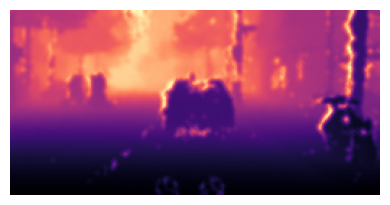

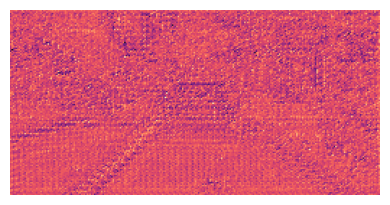

In [481]:
# depth_path = '../nyu_data/data/nyu2_train/basement_0001a_out/1.png'
# gt_depth = Image.open(depth_path)
# depth_tensor = transform(gt_depth).unsqueeze(0)  # add batch dimension
# depth_tensor = depth_tensor.to(device)
# # plt.imshow(gt_depth)
depth_to_display(depth_tensor)  # (1,1,H,W)
depth_to_display(dec_out[3])  # (1,1,H,W)



In [482]:
depth_tensor

tensor([[[[291.5888, 291.2307, 287.0863,  ..., 267.3216, 267.7464, 267.5185],
          [290.5416, 287.0091, 279.4115,  ..., 266.7148, 267.3049, 267.3049],
          [283.4809, 276.5323, 275.4069,  ..., 265.6396, 267.1089, 265.9954],
          ...,
          [110.7441, 110.7974, 110.7881,  ..., 109.8279, 109.6896, 109.5888],
          [109.7952, 109.7927, 109.8166,  ..., 108.9188, 108.8848, 108.9114],
          [109.4378, 109.3645, 109.3118,  ..., 108.5764, 108.5546, 108.5837]]]],
       device='cuda:0')

In [483]:
torch.max(depth_tensor-dec_out[3])

tensor(472.0150, device='cuda:0', grad_fn=<MaxBackward1>)

In [484]:
torch.min(depth_tensor)

tensor(108.5546, device='cuda:0')

### LOSS FUNCTIONS


In [485]:
class DepthLoss(nn.Module):

    def __init__(self, m=4, M=80):
        super(DepthLoss, self).__init__()
        self.m = m  # lower bound for log transform
        self.M = M  # upper bound for log transform
    
    def log_transform(self, depth):

        log_depth = torch.log(torch.clamp(depth, min=self.m, max=self.M))
        log_m = math.log(self.m)
        log_M = math.log(self.M)
        
        return (log_depth - log_m) * self.M / (log_M - log_m)
    
    def berhu_loss(self, pred, target, c):
 
        diff = torch.abs(pred - target)
        l1_mask = diff <= c
        l1_loss = diff
        l2_loss = (diff**2 + c**2) / (2 * c)
        
        
        return torch.where(l1_mask, l1_loss, l2_loss)
    
    def forward(self, pred_depth, gt_depth):
        pred_log = self.log_transform(pred_depth)
        gt_log = self.log_transform(gt_depth)
        
        diff = torch.abs(pred_log - gt_log)
        c = 0.2 * torch.max(diff)  
        # Apply BerHu loss
        berhu_losses = self.berhu_loss(pred_log, gt_log, c)
        
        # Average over spatial dimensions
        B, H, W = pred_depth.shape
        loss = torch.sum(berhu_losses) / (B * H * W)
        
        return loss

In [24]:
class MultiScaleDepthLoss(nn.Module):
    """
    Implements the multi-scale depth loss function described in the provided image.
    The total loss is the sum of the BerHu loss calculated at 4 different scales.
    """
    def __init__(self, m=0.1, M=10.0):
        super(MultiScaleDepthLoss, self).__init__()
        self.m = m
        self.M = M
        
        # Pre-calculate constants for the G(d) transform for efficiency
        self.log_m = math.log(self.m)
        self.log_M = math.log(self.M)
        self.log_M_minus_log_m = self.log_M - self.log_m

    def _g_transform(self, d):
        """
        Applies the G(d) log-space transformation and normalization.
        G(d) = ((log(d) - log(m)) * M) / (log(M) - log(m))
        """
        # Clamp depth values to the valid range [m, M]
        d_clamped = torch.clamp(d, min=self.m, max=self.M)
        
        log_d = torch.log(d_clamped)
        
        # Apply the transformation formula
        return (log_d - self.log_m) * self.M / self.log_M_minus_log_m

    def _berhu_loss(self, diff, c):
        """
        Calculates the Reverse Huber (BerHu) loss F(x).
        F(x) is L1 loss for |x| <= c and a L2-like loss for |x| > c.
        """
        # print("c value:",c)
        # L1 loss for small differences
        l1_loss = diff
        
        # L2-like loss for large differences
        l2_loss = (diff**2 + c**2) / (2 * c)
        
        # Combine using a mask
        mask = diff <= c
        return torch.where(mask, l1_loss, l2_loss)

    def forward(self, pred_depths, gt_depth):

        total_loss = 0.0
        scale = [0.3, 0.5, 0.75, 1.0]
        # Iterate through each predicted depth map scale
        for i,pred_d in enumerate(pred_depths):
            # Get the height and width of the current prediction scale
            _, H_i, W_i = pred_d.shape
            
            # Downsample the ground truth depth map to match the current prediction's resolution
            # Using align_corners=True is common practice for deterministic resizing
            # gt_depth = gt_depth.squeeze(dim=1).to(torch.float32)
            # print(gt_depth.shape)
            
            resized_gt_d = F.interpolate(gt_depth, size=(H_i, W_i), mode='bilinear', align_corners=True)
            resized_gt_d = resized_gt_d.squeeze(dim=1).to(torch.float32)
            # print(resized_gt_d)
            # print(pred_d)
            
            # Apply the G-transform to both prediction and resized ground truth
            pred_g = self._g_transform(pred_d)
            gt_g = self._g_transform(resized_gt_d)
            # print(pred_g)
            # print(gt_g)
            # gt_g = gt_g.squeeze(dim=1).to(torch.float32)
            # print(pred_g.shape,gt_g.shape)
            # Calculate the absolute difference in the transformed space
            diff = torch.abs(pred_g - gt_g)
            
            # Calculate the dynamic threshold 'c' (20% of the max difference in the batch)
            # .detach() is used so that the calculation of 'c' itself isn't part of the gradient graph
            # print(diff)
            c = 0.2 * torch.max(diff).detach()
            
            # Calculate the BerHu loss for every pixel
            berhu_pixel_losses = self._berhu_loss(diff, c)
            # print(berhu_pixel_losses)
            # Calculate the mean loss for the current scale and add it to the total
            scale_loss = torch.sum(berhu_pixel_losses) / ( H_i * W_i)  # Average over batch and spatial dimensions
            total_loss += scale_loss
            
        return total_loss

In [25]:
class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, data_range=1.0, size_average=True):
        super(SSIMLoss, self).__init__()
        self.window_size = window_size
        self.data_range = data_range
        self.size_average = size_average
        
        # Create Gaussian window (1, 1, window_size, window_size)
        self.window = self._create_window(window_size)
        
    def _gaussian(self, window_size, sigma=1.5):
        gauss = torch.Tensor([
            math.exp(-(x - window_size//2)**2 / (2*sigma**2)) 
            for x in range(window_size)
        ])
        return gauss / gauss.sum()
    
    def _create_window(self, window_size):
        _1D_window = self._gaussian(window_size, 1.5).unsqueeze(1)
        _2D_window = _1D_window.mm(_1D_window.t()).float()
        window = _2D_window.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, 11, 11)
        return window
    
    def forward(self, pred, target):
        pred = pred[-1]
        # Add channel dimension: (B, H, W) -> (B, 1, H, W)
        if pred.dim() == 3:
            pred = pred.unsqueeze(1)
            # target = target.unsqueeze(1)
        
        # batch_size = pred.size(0)
        
        # Ensure window is on same device
        if self.window.device != pred.device:
            self.window = self.window.to(pred.device)
        
        # Use the single-channel window
        window = self.window
        
        # Compute local means
        mu1 = F.conv2d(pred, window, padding=self.window_size//2)
        mu2 = F.conv2d(target, window, padding=self.window_size//2)
        
        mu1_sq = mu1.pow(2)
        mu2_sq = mu2.pow(2)
        mu1_mu2 = mu1 * mu2
        
        # Compute local variances and covariance
        sigma1_sq = F.conv2d(pred * pred, window, padding=self.window_size//2) - mu1_sq
        sigma2_sq = F.conv2d(target * target, window, padding=self.window_size//2) - mu2_sq
        sigma12 = F.conv2d(pred * target, window, padding=self.window_size//2) - mu1_mu2
        
        # SSIM constants
        C1 = (0.01 * self.data_range) ** 2
        C2 = (0.03 * self.data_range) ** 2
        
        # SSIM formula
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        
        # Average over spatial dimensions, optionally over batch
        if self.size_average:
            return 1 - ssim_map.mean()  # Convert to loss
        else:
            return 1 - ssim_map.mean(dim=[1, 2, 3])  # Per-batch losses

In [26]:
def edge_aware_smoothness_loss( pred, depth):    
    # Compute gradients
    pred = pred[-1]
    depth = depth.squeeze(dim=1).to(torch.float32)
    depth_grad_x = torch.abs(depth[:, :, :-1] - depth[:, :, 1:])
    depth_grad_y = torch.abs(depth[:, :-1, :] - depth[:, 1:, :])

    image_grad_x = torch.abs(pred[:,  :, :-1] - pred[:,  :, 1:])
    image_grad_y = torch.abs(pred[:,  :-1, :] - pred[:, 1:, :])

    # Edge-aware weighting
    # smooth_x = depth_grad_x * torch.exp(-image_grad_x)
    # smooth_y = depth_grad_y * torch.exp(-image_grad_y)
    loss = torch.sum(torch.abs(depth_grad_x - image_grad_x)) + torch.sum(torch.abs(depth_grad_y - image_grad_y))
    loss /= (pred.size(1) * pred.size(2))

    return loss


In [27]:
class ModifiedLoss(nn.Module):
    def __init__(self, m=0.5, M=80.0):
        super(ModifiedLoss, self).__init__()
        # self.depth_loss_fn = MultiScaleDepthLoss(m, M)
        # self.alpha = alpha
        # self.ce_loss_fn = nn.CrossEntropyLoss()
    
    def forward(self, pred_depths, gt_depth):
        # H_i, W_i = pred_depths[-1].shape[1], pred_depths[-1].shape[2]
        # out_depth = pred_depths[-1]
        # gt_depth = gt_depth.squeeze(dim=1).to(torch.float32)
        
        # loss1 = torch.abs(out_depth - gt_depth) / (H_i * W_i)

        # grad_loss = 

        # loss_ssim = 

        total_loss = depth_loss + self.alpha * segm_loss
        return total_loss

In [28]:
loss = MultiScaleDepthLoss()
# depth_tensor
# dec_out = dec_out.float()
depth_tensor = depth_tensor.float()
testing_loss = edge_aware_smoothness_loss(dec_out, depth_tensor)
print(testing_loss,loss(dec_out, depth_tensor))


tensor(2.3323, device='cuda:0', grad_fn=<DivBackward0>) tensor(11.9030, device='cuda:0', grad_fn=<AddBackward0>)


## Dataset Prep


In [29]:
train_csv = '../nyu_data/data/nyu2_train.csv'
base_path = '../nyu_data'
df = pd.read_csv(train_csv, header=None)
df[0] = df[0].map(lambda x: base_path+"/"+x) # Prepending the base path
df[1] = df[1].map(lambda x: base_path+"/"+x)

In [30]:
df.iloc[0,0], df.iloc[0,1]  # Checking the paths

('../nyu_data/data/nyu2_train/living_room_0038_out/37.jpg',
 '../nyu_data/data/nyu2_train/living_room_0038_out/37.png')

In [31]:
df.head()

,0,1
0,../nyu_data/data/nyu2_train/living_room_0038_o...,../nyu_data/data/nyu2_train/living_room_0038_o...
1,../nyu_data/data/nyu2_train/living_room_0038_o...,../nyu_data/data/nyu2_train/living_room_0038_o...
2,../nyu_data/data/nyu2_train/living_room_0038_o...,../nyu_data/data/nyu2_train/living_room_0038_o...
3,../nyu_data/data/nyu2_train/living_room_0038_o...,../nyu_data/data/nyu2_train/living_room_0038_o...
4,../nyu_data/data/nyu2_train/living_room_0038_o...,../nyu_data/data/nyu2_train/living_room_0038_o...


In [32]:
class DepthDataset(Dataset):

    def __init__(self, df, image_transform=None, depth_transform=None):
    
        self.df = df
        self.image_transform = image_transform
        self.depth_transform = depth_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get the file paths from the dataframe at the given index
        image_path = self.df.iloc[idx, 0]
        depth_path = self.df.iloc[idx, 1]
        
        # Load the image and depth map using PIL
        image = transforms.ToTensor()(Image.open(image_path))
        depth = transforms.ToTensor()(Image.open(depth_path))

        # Apply transformations if they are provided
        if self.image_transform:
            image = self.image_transform(image)
        
        if self.depth_transform:
            depth = self.depth_transform(depth)

        return image, depth

In [33]:
dataset_depth = DepthDataset(df)
data_loader_depth = DataLoader(dataset_depth, batch_size=8, shuffle=True, num_workers=2)
for batch in data_loader_depth:
    print(batch[0].shape)  # Should be (B, 3, H, W)
    print(batch[1].shape)  # Should be (B, 1, H, W)
    break

torch.Size([8, 3, 480, 640])
torch.Size([8, 1, 480, 640])


In [34]:
import torch.optim.lr_scheduler as lr_scheduler


In [35]:
def train_multi_scale_depth_model(model, dataloader, num_epochs=100, lr=1e-2):
    # # Initialize dataset and dataloader
    # dataset = DepthDataset(dataset_folder)
    # dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize loss function and optimizer
    depth_loss = MultiScaleDepthLoss()
    ssim_loss = SSIMLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # scheduler = StepLR(optimizer, step_size=1, gamma=0.9)
    # Cosine Annealing with Warm Restarts
    scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=5,        # Epochs until first restart
        T_mult=2,      # Multiply restart period by this factor
        eta_min=1e-5  # Minimum learning rate
    )
    # Scale weights for different depth layers (coarse to fine)
    # scale_weights = [1, 1, 1, 1.0]  # Give more weight to finer scales
    
    model.train()
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        
        for batch_idx, (color_input, depth_gt) in enumerate(dataloader):

            if batch_idx > 1000:
                break
            if batch_idx % 50 == 0:
                # print(f"Processing batch {batch_idx} of epoch {epoch}")
                scheduler.step()
            color_input = color_input.to(device, non_blocking=True)
            depth_gt = depth_gt.to(device, non_blocking=True)
            
            # Ensure data types are consistent
            color_input = color_input.float()
            depth_gt = depth_gt.float()
            
            optimizer.zero_grad()
            
            # Forward pass through model - returns list of 4 depth predictions
            depth_predictions = model(color_input)  # List of 4 tensors at different scales
            total_loss = 0.0
            
            layer_losses = []
            
            # Compute loss for each depth layer
            # for i, (pred_depth, weight) in enumerate(zip(depth_predictions, scale_weights)):
            #     # Resize ground truth to match prediction resolution if needed
            #     # print("pred_depth shape:", pred_depth.shape)
            #     if pred_depth.shape[-2:] != depth_gt.shape[-2:]:
            #         depth_gt_resized = torch.nn.functional.interpolate(
            #             depth_gt, size=pred_depth.shape[-2:], mode='bilinear', align_corners=False
            #         )
            #     else:
            #         depth_gt_resized = depth_gt
                
            #     # Compute loss for this layer
            #     layer_loss = depth_loss(pred_depth, depth_gt_resized)
            #     weighted_loss = weight * layer_loss
            #     total_loss += weighted_loss
            #     layer_losses.append(layer_loss.item())
            total_loss = depth_loss(depth_predictions, depth_gt) + edge_aware_smoothness_loss(depth_predictions, depth_gt) + ssim_loss(depth_predictions, depth_gt) 

            # Backward pass
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            
            # Print progress
            if batch_idx % 50 == 0:
                print(f'Epoch {epoch}/{num_epochs}, Batch {batch_idx}, '
                      f'Total Loss: {total_loss.item():.4f}, ')
                    #   f'Layer Losses: {[f"{l:.4f}" for l in layer_losses]}')
        
        print(f'Epoch {epoch} completed. Average Loss: {epoch_loss/len(dataloader):.4f}')
        # scheduler.step()

In [36]:
def train_multi_scale_depth_model_with_checks(model, dataset_folder, num_epochs=100, batch_size=4, lr=1e-4):
    # Explicit device checking
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print("CUDA is available! Training on GPU...")
    else:
        device = torch.device('cpu')
        print("CUDA is not available. Training on CPU...")
    
    # Move model to device
    # model = model.to(device)
    
    # Initialize dataset and dataloader
    dataset = DepthDataset(dataset_folder)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                          pin_memory=torch.cuda.is_available(), num_workers=2)
    
    # Initialize loss function and optimizer
    depth_loss = DepthLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Scale weights for different depth layers
    scale_weights = [0.5, 0.7, 0.9, 1.0]
    
    model.train()
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        
        for batch_idx, (color_input, depth_gt) in enumerate(dataloader):
            # Move tensors to GPU if CUDA is available
            color_input = color_input.to(device, non_blocking=True)
            depth_gt = depth_gt.to(device, non_blocking=True)
            
            # Ensure data types are consistent
            color_input = color_input.float()
            depth_gt = depth_gt.float()
            
            optimizer.zero_grad()
            
            # Forward pass through model
            depth_predictions = model(color_input)
            
            total_loss = 0.0
            layer_losses = []
            
            # Compute loss for each depth layer
            for i, (pred_depth, weight) in enumerate(zip(depth_predictions, scale_weights)):
                # Resize ground truth to match prediction resolution if needed
                if pred_depth.shape[-2:] != depth_gt.shape[-2:]:
                    depth_gt_resized = torch.nn.functional.interpolate(
                        depth_gt, size=pred_depth.shape[-2:], mode='bilinear', align_corners=False
                    )
                else:
                    depth_gt_resized = depth_gt
                
                # Compute loss for this layer
                layer_loss = depth_loss(pred_depth, depth_gt_resized)
                weighted_loss = weight * layer_loss
                total_loss += weighted_loss
                layer_losses.append(layer_loss.item())
            
            # Backward pass
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            
            # Print progress
            if batch_idx % 10 == 0:
                print(f'Epoch {epoch}/{num_epochs}, Batch {batch_idx}, '
                      f'Total Loss: {total_loss.item():.4f}, '
                      f'Device: {color_input.device}, '
                      f'Layer Losses: {[f"{l:.4f}" for l in layer_losses]}')
        
        print(f'Epoch {epoch} completed. Average Loss: {epoch_loss/len(dataloader):.4f}')



In [37]:
train_multi_scale_depth_model(model, data_loader_depth, num_epochs=20, lr=1e-2)

Epoch 0/20, Batch 0, Total Loss: 102.5533, 
Epoch 0/20, Batch 50, Total Loss: 42.5998, 
Epoch 0/20, Batch 100, Total Loss: 25.8585, 
Epoch 0/20, Batch 150, Total Loss: 33.9936, 
Epoch 0/20, Batch 200, Total Loss: 31.7549, 
Epoch 0/20, Batch 250, Total Loss: 34.7539, 
Epoch 0/20, Batch 300, Total Loss: 34.5709, 
Epoch 0/20, Batch 350, Total Loss: 27.1354, 
Epoch 0/20, Batch 400, Total Loss: 31.8072, 
Epoch 0/20, Batch 450, Total Loss: 30.8089, 
Epoch 0/20, Batch 500, Total Loss: 26.6297, 
Epoch 0/20, Batch 550, Total Loss: 25.9162, 
Epoch 0/20, Batch 600, Total Loss: 28.7489, 


KeyboardInterrupt: 

In [39]:
output = model(img_tensor)

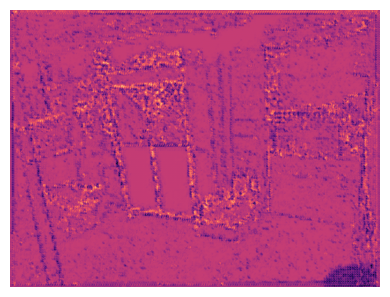

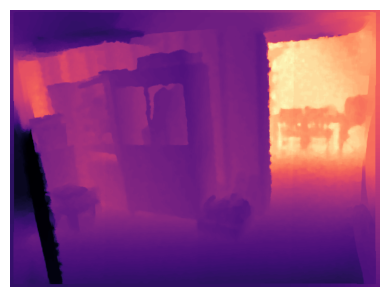

In [40]:
depth_to_display(output[3])  # (1,1,H,W)
depth_to_display(depth_tensor)  # (1,1,H,W)

In [ ]:
mbnetv2 = mbnetv2()

Initializing weights...


In [ ]:
encoder_params = sum(p.numel() for p in mbnetv2.parameters())
print(f'Encoder parameters: {encoder_params}')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total number of parameters: {total_params}')
print(f'Total decoder parameters: {total_params - encoder_params}')


Encoder parameters: 3504872
Total number of parameters: 3556290
Total decoder parameters: 51418


In [ ]:
def rmse(pred, target):
    pred = pred[-1]
    return torch.sqrt(torch.mean((pred - target) ** 2))

In [ ]:
rmse(output, depth_tensor)

tensor(0.1246, device='cuda:0', grad_fn=<SqrtBackward0>)

In [ ]:
print(torch.max(output[3]).item(),
torch.max(depth_tensor).item(),
torch.min(torch.abs(output[3]-depth_tensor)).item())

0.7858999967575073 0.658823549747467 2.130866050720215e-06


In [ ]:
# torch.save(model.state_dict(), '../saves/v2.pth')


In [ ]:
def smooth_depth_prediction(depth_tensor, kernel_size=5):
    """Apply Gaussian smoothing to reduce noise"""
    import torch.nn.functional as F
    
    # Create Gaussian kernel
    sigma = kernel_size / 3.0
    kernel_1d = torch.exp(-0.5 * (torch.arange(kernel_size) - kernel_size//2)**2 / sigma**2)
    kernel_1d = kernel_1d / kernel_1d.sum()
    
    # 2D separable Gaussian
    kernel_2d = kernel_1d[:, None] * kernel_1d[None, :]
    kernel_2d = kernel_2d.unsqueeze(0).unsqueeze(0).to(depth_tensor.device)
    
    # Apply smoothing
    smooth_depth = F.conv2d(depth_tensor, kernel_2d, padding=kernel_size//2)
    return smooth_depth

# Use during inference
with torch.no_grad():
    raw_pred = model(img_tensor)
    smooth_pred = smooth_depth_prediction(raw_pred[-1])


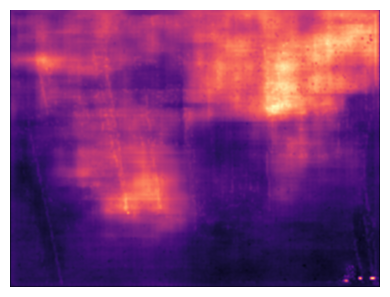

In [ ]:
depth_to_display(smooth_pred)